# Overview

*Run in the `modiscolite` conda environment*

Here, we convert CWMs to PPMs and eventually PWMs. We save the PWMs for the **508 unique motifs** in our annotated set.

The procedure we use to get to probability matrices is as follows:

1. Min max normalize each position $\frac{(x - min)*}{(max - min)}$, where x is the value of some base at the position, max is the maximum score over all bases at the position, min is the minimum score over all bases at the position
2. Normalize each column to a probability distribution so they sum to 1. $\frac{x_{norm}}{sum(x_{norm})}$ where $sum(x_{norm})$ is the sum of the $x_{norm}$ scores over all bases at the position

For visualization, it's helpful to see the motif plotted with information (in bits)
rather than probabilities. We use the built-in function in `logomaker` for this, which computes the following ([source](https://logomaker.readthedocs.io/en/latest/implementation.html#matrix-functions)):

$I_{ic} = P_{ic} * sum_d(P_{id} * log_2(\frac{P_{id}}{W_{id}}))$

$i$ = position $c$   
$d$ = character  
$l$ = pseudocount  
$C$ = number of characters  
$N_{ic}$ = counts matrix element  
$P_{ic}$ = probability matrix element  
$W_{ic}$ = weight matrix element  
$I_{ic}$ = information matrix element  

_NOTE_: Regarding repressive motifs with negative contribution
scores, those aren't handled by MEME format. (That's an inherent advantage of
MoDIsco/SHAPs and a limitation of sequence-scanning.) The resulting PPMs/PWMs 
are all positive.

#  Set up

In [7]:
%load_ext autoreload
%autoreload 2

# deal with matplotlib plots
%matplotlib inline

# display all outputs in a cell
get_ipython().ast_node_interactivity = 'all'

from IPython.display import display, HTML

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# misc
import os
import sys
import numpy as np
import random
from tqdm import tqdm
import pandas as pd

# io
import h5py

# ML
import modiscolite
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('white')
import logomaker

print(modiscolite.__version__)
print(np.__version__)

sys.path.append("..")
import chrombpnet_utils as cutils
from chrombpnet_utils.plot import df,plot_logo
from chrombpnet_utils.modisco import trim_cwm

# editable text in PDFs
# https://stackoverflow.com/a/54111532
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

2.2.0
1.24.3


# Load data

Let's load CWMs from our joint modisco object.

In [16]:
# set paths
hdma_path = "../../../"
hdma_chrombpnet_path = hdma_path + "output/03-chrombpnet/"
compiled_modisco_h5_path = hdma_chrombpnet_path + "02-compendium/modisco_compiled/modisco_compiled.h5"
# modisco_compiled_unique = hdma_path + "chrombpnet/output/03-grammar/01/motifs_compiled_unique_short.tsv"

In [17]:
# load annotated motifs
motifs_compiled = pd.read_csv("04d-ChromBPNet_de_novo_motifs.tsv", sep = "\t")
motifs_compiled["motif_name"] = motifs_compiled['idx_uniq'].map(str) + '|' + motifs_compiled['annotation']
motifs_compiled[["idx_uniq", "motif_name", "pattern", "annotation", "category", "total_n_seqlets"]]

# keep only the first entry per motif_name, sorting by total_n_seqlets

,idx_uniq,motif_name,pattern,annotation,category,total_n_seqlets
0,0,0|AP-2,pos.Average_272__merged_pattern_1,AP-2,base,12769
1,0,0|AP-2,pos.Average_272__merged_pattern_3,AP-2,base,26
2,1,1|AP-2_BHLH,pos.Average_272__merged_pattern_4,AP-2_BHLH,composite_hetero,25
3,2,2|ATF4/CEBPG,pos.Average_280__merged_pattern_22,ATF4/CEBPG,composite_hetero,305
4,2,2|ATF4/CEBPG,pos.Average_85__merged_pattern_1,ATF4/CEBPG,composite_hetero,4594
...,...,...,...,...,...,...
829,462,462|ZNF143#1,pos.Average_161__merged_pattern_2,ZNF143#1,base,830
830,462,462|ZNF143#1,pos.Average_161__merged_pattern_5,ZNF143#1,base,56
831,463,463|ZNF143#2,pos.Average_161__merged_pattern_1,ZNF143#2,base,29533
832,464,464|ZNF143#3,pos.Average_161__merged_pattern_3,ZNF143#3,base,384


In [62]:
# for each broad motif annotation, choose the actual motif (= moidsco pattern) w/ the most seqlets
motifs_compiled_unique = motifs_compiled.sort_values('total_n_seqlets', ascending = False).groupby('motif_name').first().sort_values('idx_uniq').reset_index()

# remove the excluded motif
motifs_compiled_unique = motifs_compiled_unique[motifs_compiled_unique['motif_name'] != '466|exclude']

# remove the excluded motif
motifs_compiled_unique
len(motifs_compiled_unique)

,motif_name,idx,pattern_class,pattern,total_n_seqlets,n_component_patterns,n_component_celltypes,n_component_organs,component_organs,component_celltypes,...,match0_jolma,qval0_jolma,match0_logo_jolma,match1,qval1,match1_logo,match2,qval2,match2_logo,idx_uniq
0,0|AP-2,182,pos,pos.Average_272__merged_pattern_1,12769,6,6,2,"Eye,Skin","horizontal,amacrine,melanocyte,interfollicular cells,epidermal progenitor,keratinocyte",...,ETS_PAX|ELK1_PAX1,0.999999,NaN,TFAP2A: M07784_2.00,7.630000e-07,NaN,TFAP2A: MA0003.2,0.000002,NaN,0
1,1|AP-2_BHLH,185,pos,pos.Average_272__merged_pattern_4,25,1,1,1,Skin,melanocyte,...,bZIP_bZIP|ATF4_TEF,0.999955,NaN,TFAP2E: M04053_2.00,1.037210e-02,NaN,TFAP2E: M04051_2.00,0.010372,NaN,1
2,2|ATF4/CEBPG,721,pos,pos.Average_85__merged_pattern_1,4594,6,6,2,"Muscle,Skin","smooth muscle,keratinocytes,fibroblast,keratinocyte,skeletal muscle",...,bZIP_bZIP|ATF4_TEF,0.000181,NaN,CEBPG: MA1636.1,1.131450e-02,NaN,ATF4: M08796_2.00,0.011314,NaN,2
3,3|BANP/ZBTB33,716,pos,pos.Average_64__merged_pattern_0,73679,187,187,12,"Adrenal,Brain,Eye,Heart,Liver,Lung,Muscle,Skin,Spleen,StomachEsophagus,Thymus,Thyroid","adrenal cortex,excitatory neurons,dorsal radial glia,CGE-derived inhibitory neurons,smooth muscle cells,endothelial,oligodendrocyte precursor cells,MGE-derived inhibitory neurons,retinal progenitor cell,fibroblast,RPE,horizontal,smooth muscle,astrocyte,myogenic progenitor,ciliated pigmented epithelium,schwann,melanocyte,immune,rod,amacrine,trabecular meshwork,extraocular muscle,retinal ganglion,bipolar,cone,vascular endothelium,vCM,endocardial,neuronal,epicardial,aCM,cycling vCM,pericyte,ery...",...,ETS_Tbox|ETV5_EOMES,0.999966,NaN,ZBTB33: M08094_2.00,6.750000e-06,NaN,ZBTB33: MA0527.1,0.000007,NaN,3
4,4|BCL11A/Brepressive,832,neg,neg.Thymus__Average_6__merged_pattern_0,192,3,3,1,Thymus,CD8+ CD4+ thymocytes,...,ETS_Homeo|ETV2_EVX1,1.000000,NaN,REST: M09501_2.00,1.000000e+00,NaN,ZNF296: M04544_2.00,1.000000,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504,"504|unresolved,palindromic#2",778,pos,pos.Skin__Skin_c2__pos_patterns.pattern_45__merged_pattern_0,30,1,1,1,Skin,keratinocyte,...,ETS_bHLH|ETV5_FIGLA,0.153000,NaN,TP63: MA0525.2,6.051370e-01,NaN,TP63: M03437_2.00,0.605000,NaN,504
505,"505|unresolved,repressive#1",831,neg,neg.Thymus__Average_4__merged_pattern_2,23,1,1,1,Thymus,CD8+ CD4+ thymocytes,...,ETS_bHLH|ELK1_SREBF2,0.999135,NaN,TEAD1: MA0090.3,7.813670e-01,NaN,ZNF502: M08947_2.00,0.781367,NaN,505
506,"506|unresolved,repressive#2",824,neg,neg.Average_16__merged_pattern_0,47,2,2,2,"Brain,Eye","dorsal radial glia,fibroblast",...,ETS_bZIP|ETV2_TEF,0.462939,NaN,STAT3: M09415_2.00,1.000000e+00,NaN,ZNF28: M07748_2.00,1.000000,NaN,506
507,"507|unresolved,repressive,YY1/2-like",823,neg,neg.Average_15__merged_pattern_1,35,1,1,1,Lung,airway epithelial progenitor,...,ETS_Homeo|ELK1_HOXA3,0.170000,NaN,ATF4: MA0833.2,1.000000e+00,NaN,JUN: MA0488.1,1.000000,NaN,507


508

In [19]:
motifs_compiled_unique[motifs_compiled_unique['motif_name'] == '374|NKX#2']

,motif_name,idx,pattern_class,pattern,total_n_seqlets,n_component_patterns,n_component_celltypes,n_component_organs,component_organs,component_celltypes,...,match0_jolma,qval0_jolma,match0_logo_jolma,match1,qval1,match1_logo,match2,qval2,match2_logo,idx_uniq
374,374|NKX#2,296,pos,pos.Average_280__merged_pattern_1,84968,41,19,4,"Brain,Lung,Muscle,Thyroid","endothelial,smooth muscle cells,airway epithelial progenitor,airway fibroblast,lymphatics,immune,pulmonary neuroendocrine,ciliated,vascular endothelial,pericytes,smooth muscle,thyroid follicular",...,ETS_PAX|ELK1_PAX9,0.999981,NaN,NKX2-8: M05151_2.00,0.007887,NaN,NKX2-3: M05045_2.00,0.028846,NaN,374


In [20]:
# load up the modisco compiled object
modisco_obj = h5py.File(compiled_modisco_h5_path)

In [21]:
len(modisco_obj['pos_patterns'].keys())
len(modisco_obj['neg_patterns'].keys())

805

29

In [22]:
modisco_obj['pos_patterns']['pos.Average_305__merged_pattern_0']['contrib_scores'][()].shape

(30, 4)

## Helper functions

In [23]:
# helper function to get the motif name
def get_motif_name(motif_id):
	"""
	Get the motif name (with unique index) for a given motif, using its MoDISco pattern name '<pattern_class>.pattern_<X>'.
	"""
	return motifs_compiled[motifs_compiled["pattern"] == motif_id]['motif_name'].values[0]

# Example usage
motif_id = "pos.Average_229__merged_pattern_0"
motif_name = get_motif_name(motif_id)
print(motif_name)

467|p53_p53#1


In [24]:
def convert_cwm_to_ppm(cwm):
	"""
	Convert a MoDISco-derived CWM to a PPM using this procedure, adapted from Anshul:
	1. Min max normalize each position (x - min) / (max - min), where x is the value of some base at the position, max is the maximum score over all bases at the position, min is the minimum score over all bases at the position
	2. Normalize each column to a probability distribution so they sum to 1. norm_x / sum(norm_x) where sum(norm_x) is the sum of the norm_x scores over all bases at the position
	
	Args:
		cwm (np.array): the CWM to convert to a PPM, with shape (L, 4) where L is the number of positions and 4 is the number of bases	
    """

	# min-max normalization
	min_vals = np.min(cwm, axis=1, keepdims=True)
	max_vals = np.max(cwm, axis=1, keepdims=True)
	norm_cwm = (cwm - min_vals) / (max_vals - min_vals)

	# norm to probability distribution
	ppm = norm_cwm / np.sum(norm_cwm, axis=1, keepdims=True)
	
	return ppm

In [25]:
def write_cwm_ppm_to_meme(modisco_obj, motif_annotations, meme_out, trim = False, trim_threshold = 0.3):
	"""
	Convert CWMs to PPMs and write them to a MEME file.

	Based on code from Jacob Schreiber and Ivy Raine in tfmodisco-lite:
	https://github.com/jmschrei/tfmodisco-lite/blob/3c6e38f3ad5df80c55bd4e8c7c2a531ee0a2b316/modiscolite/io.py#L221C1-L273C29

	Args:
		modisco_obj (h5py.File): The MoDISco object containing CWMs.
		motif_annotations (pd.DataFrame): DataFrame containing motif annotations.
		meme_out (str): Path to the output MEME file.
	"""
	# delete the file if it exists
	if os.path.exists(meme_out):
		os.remove(meme_out)

	alphabet = 'ACGT'
	writer = modiscolite.meme_writer.MEMEWriter(
		memesuite_version='5',
		alphabet=alphabet,
		background_frequencies='A 0.25 C 0.25 G 0.25 T 0.25'
	)
	writer.motifs.clear()

	print(len(writer.motifs))

	# iterate over groups
	pattern_classes = list(modisco_obj.keys())

	for pattern_class in pattern_classes:

		for (motif_id, datasets) in tqdm(modisco_obj[pattern_class].items()):

			# check if the motif is in a merged, annotated pattern
			if motif_id in motif_annotations['pattern'].values:

				# get the motif annotation (readable name)
				motif_name = get_motif_name(motif_id)

				print(f"Writing {motif_id}: {motif_name}")

				cwm = datasets['contrib_scores'][()]

				# trim if necessary
				if trim:

					print("@ trimming CWMs...")
					cwm, _, _ = trim_cwm(cwm, flank = 0)
					# score = np.sum(np.abs(cwm), axis=1)
					# trim_thresh = np.max(score) * trim_threshold  # Cut off anything less than 30% of max score
					# pass_inds = np.where(score >= trim_thresh)[0]
					# cwm = cwm[np.min(pass_inds): np.max(pass_inds) + 1]

				ppm = convert_cwm_to_ppm(cwm)

				motif = modiscolite.meme_writer.MEMEWriterMotif(
					name=motif_name,
					probability_matrix=ppm,
					source_sites=1,
					alphabet=alphabet,
					alphabet_length=4
				)

				writer.add_motif(motif)

	writer.write(meme_out)
	print(len(writer.motifs))

# Inspect some CWMs

This is the CWM for a CTCF motif:

(4, 30)

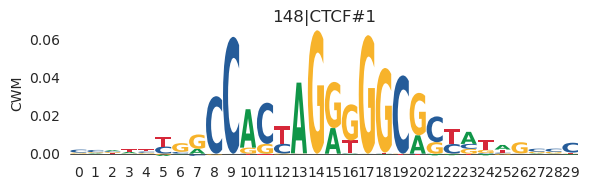

In [26]:
matrix = modisco_obj['pos_patterns']['pos.Average_305__merged_pattern_0']['contrib_scores'][()].T
title = get_motif_name("pos.Average_305__merged_pattern_0")
plot_logo(matrix, title)
matrix.shape

And CWM for a p53 motif:

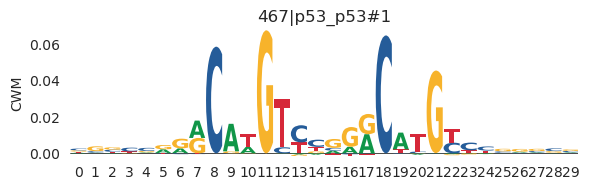

In [27]:
plot_logo(modisco_obj['pos_patterns']['pos.Average_229__merged_pattern_0']['contrib_scores'][()].T, get_motif_name("pos.Average_229__merged_pattern_0"))

And one for a BHLH motif:

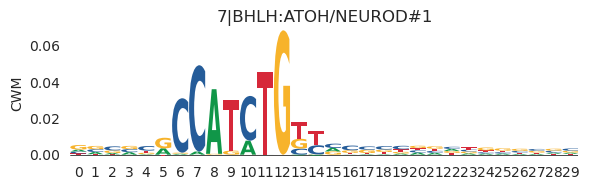

In [28]:
plot_logo(modisco_obj['pos_patterns']['pos.Average_276__merged_pattern_3']['contrib_scores'][()].T, get_motif_name("pos.Average_276__merged_pattern_3"))

And a MEIS/TBX motif:

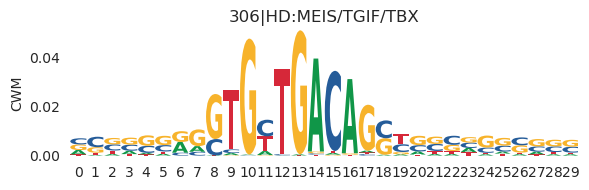

In [29]:
plot_logo(modisco_obj['pos_patterns']['pos.Average_276__merged_pattern_4']['contrib_scores'][()].T, get_motif_name("pos.Average_276__merged_pattern_4"))

# Converting CWMs to PPMs

In [30]:
cwm = modisco_obj['pos_patterns']['pos.Average_276__merged_pattern_3']['contrib_scores'][()]
cwm.shape
df(cwm)

(30, 4)

,A,C,G,T
0,0.001065,0.001049,0.002538,0.000716
1,0.001205,0.001575,0.001805,0.000259
2,0.000740,0.002264,0.001422,0.000184
3,0.001383,0.001710,0.001775,-0.000215
4,0.000302,0.002534,0.000792,0.001148
5,0.003510,-0.000016,0.005830,-0.000845
6,0.000542,0.029974,0.000603,-0.000085
7,0.001727,0.047578,0.000008,0.000003
8,0.035629,0.000003,0.000476,-0.000095
9,0.000002,-0.000049,0.002258,0.027850


In [31]:
ppm = convert_cwm_to_ppm(cwm)
df(ppm)
ppm.shape

,A,C,G,T
0,0.139321,0.132986,0.727693,0.000000
1,0.248257,0.345663,0.406080,0.000000
2,0.143511,0.536974,0.319515,0.000000
3,0.289907,0.349103,0.360990,0.000000
4,0.000000,0.625477,0.137358,0.237166
5,0.367243,0.069916,0.562842,0.000000
6,0.019985,0.958084,0.021931,0.000000
7,0.034953,0.964952,0.000095,0.000000
8,0.981629,0.002690,0.015680,0.000000
9,0.001689,0.000000,0.076240,0.922071


(30, 4)

Convert to information using logomaker's built-in function, just for visualization:

In [32]:
ppm_ic = logomaker.transform_matrix(df(ppm), from_type='probability', to_type='information')
ppm_ic

,A,C,G,T
pos,,,,
0,0.123027,0.117432,0.642585,0.000000
1,0.110042,0.153218,0.179999,0.000000
2,0.084731,0.317039,0.188647,0.000000
3,0.122181,0.147129,0.152139,0.000000
4,0.000000,0.432089,0.094889,0.163838
5,0.269630,0.051332,0.413239,0.000000
6,0.034117,1.635584,0.037439,0.000000
7,0.062214,1.717557,0.000170,0.000000
8,1.822660,0.004996,0.029114,0.000000


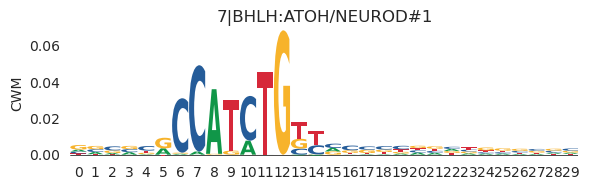

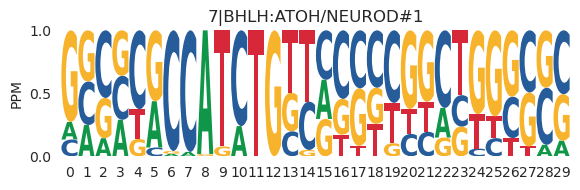

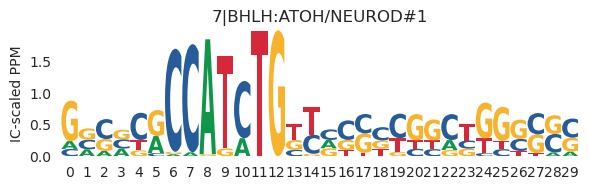

In [33]:
plot_logo(cwm.T, get_motif_name("pos.Average_276__merged_pattern_3"), type="CWM")
plot_logo(ppm.T, get_motif_name("pos.Average_276__merged_pattern_3"), type="PPM")
plot_logo(ppm_ic.T, get_motif_name("pos.Average_276__merged_pattern_3"), type="IC-scaled PPM")

Let's look at these versions across several motifs.

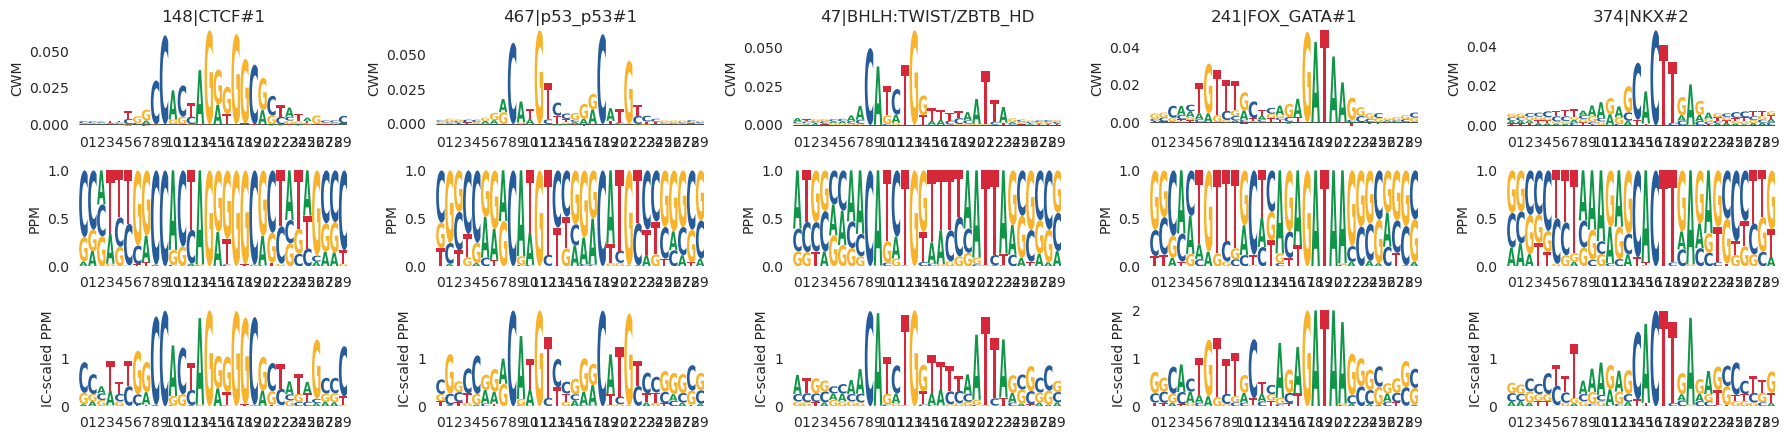

In [34]:
# make a 3x5 plot showing CWM, PPM, and IC-scaled PPMs for 5 motifs
# get the motif IDs
motif_ids = [
	"pos.Average_305__merged_pattern_0",
	"pos.Average_229__merged_pattern_0",
	"pos.Average_303__merged_pattern_0",
	"pos.Average_248__merged_pattern_11",
	"pos.Average_280__merged_pattern_1"
]

fig, ax = plt.subplots(3, 5, figsize=(18, 4.5))

for i, motif_id in enumerate(motif_ids):

	# get the CWM
	cwm = modisco_obj['pos_patterns'][motif_id]['contrib_scores'][()]
	
	# get the motif name
	motif_name = get_motif_name(motif_id)
	
	# convert to PPM
	ppm = convert_cwm_to_ppm(cwm)
	
	# convert to IC-scaled PPM
	ppm_ic = logomaker.transform_matrix(df(ppm), from_type='probability', to_type='information')
	
	# plot
	plot_logo(cwm.T, motif_name, type="CWM", ax = ax[0, i])
	plot_logo(ppm.T, "", type="PPM", ax = ax[1, i])
	plot_logo(ppm_ic.T, "", type="IC-scaled PPM", ax = ax[2, i])

plt.tight_layout()
plt.show();

# Convert all CWMs to PPMs

In [35]:
# convert all CWMs in the MoDISco object to PPMs
ppm_dict = {}
ppm_trimmed_dict = {}

# iterate over groups
pattern_classes = list(modisco_obj.keys())

for pattern_class in pattern_classes:
	
	for motif_id in tqdm(modisco_obj[pattern_class].keys()):

		# check if the motif is in a merged, annotated pattern
		if motif_id in motifs_compiled_unique['pattern'].values:
	
			cwm = modisco_obj[pattern_class][motif_id]['contrib_scores'][()]
			ppm = convert_cwm_to_ppm(cwm)
			ppm_dict[motif_id] = ppm
	
			cwm_trimmed, _, _ = trim_cwm(cwm, flank = 0)
			ppm_trimmed = convert_cwm_to_ppm(cwm_trimmed)
			ppm_trimmed_dict[motif_id] = ppm_trimmed

100%|██████████| 805/805 [00:00<00:00, 1920.11it/s]


In [36]:
len(ppm_dict)
len(ppm_trimmed_dict)

508

508

Inspect some random motifs:

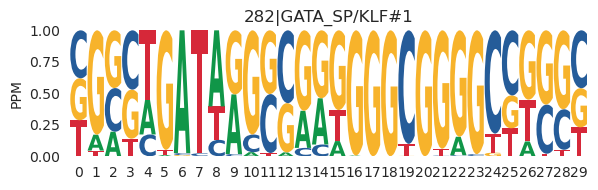

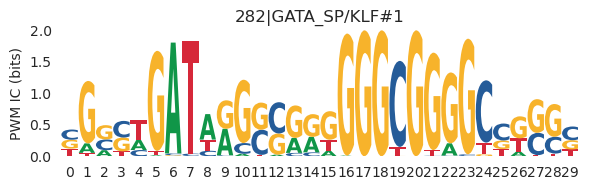

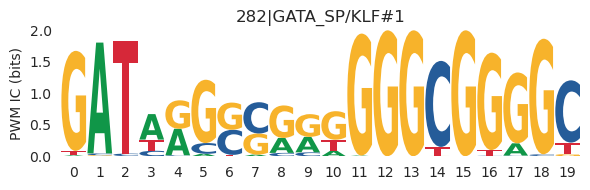

In [37]:
plot_logo(ppm_dict['pos.Average_212__merged_pattern_21'].T, get_motif_name('pos.Average_212__merged_pattern_21'), type = "PPM")
plot_logo(ppm_dict['pos.Average_212__merged_pattern_21'].T, get_motif_name('pos.Average_212__merged_pattern_21'), type = "PPM", plot_IC=True)
plot_logo(ppm_trimmed_dict['pos.Average_212__merged_pattern_21'].T, get_motif_name('pos.Average_212__merged_pattern_21'), type = "PPM", plot_IC=True)

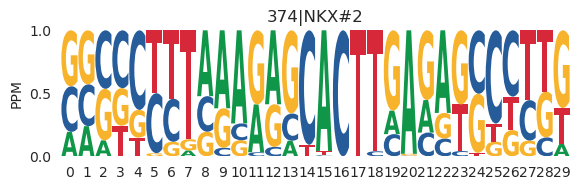

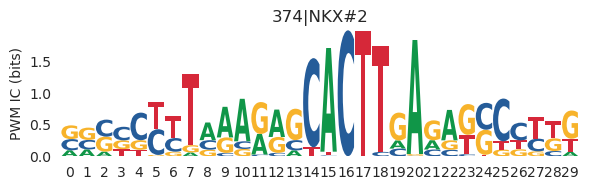

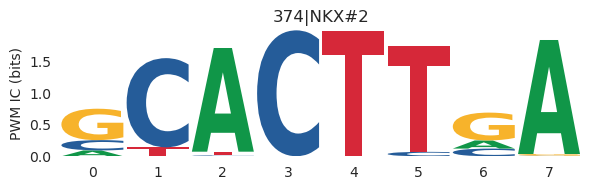

In [38]:
plot_logo(ppm_dict['pos.Average_280__merged_pattern_1'].T, get_motif_name('pos.Average_280__merged_pattern_1'), type = "PPM")
plot_logo(ppm_dict['pos.Average_280__merged_pattern_1'].T, get_motif_name('pos.Average_280__merged_pattern_1'), type = "PPM", plot_IC=True)
plot_logo(ppm_trimmed_dict['pos.Average_280__merged_pattern_1'].T, get_motif_name('pos.Average_280__merged_pattern_1'), type = "PPM", plot_IC=True)

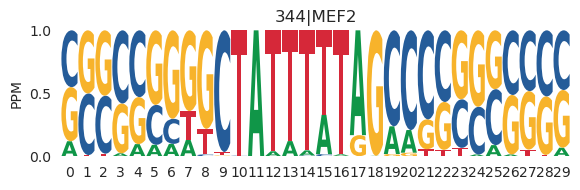

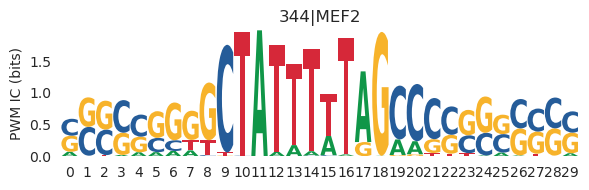

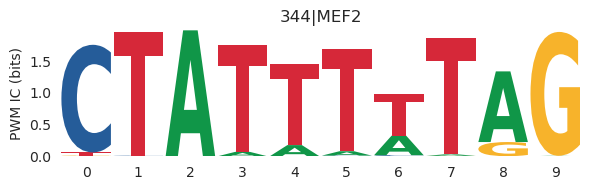

In [39]:
plot_logo(ppm_dict['pos.Average_295__merged_pattern_0'].T, get_motif_name('pos.Average_295__merged_pattern_0'), type = "PPM")
plot_logo(ppm_dict['pos.Average_295__merged_pattern_0'].T, get_motif_name('pos.Average_295__merged_pattern_0'), type = "PPM", plot_IC=True)
plot_logo(ppm_trimmed_dict['pos.Average_295__merged_pattern_0'].T, get_motif_name('pos.Average_295__merged_pattern_0'), type = "PPM", plot_IC=True)

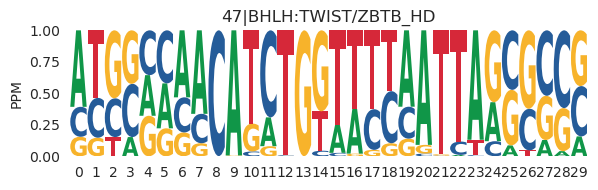

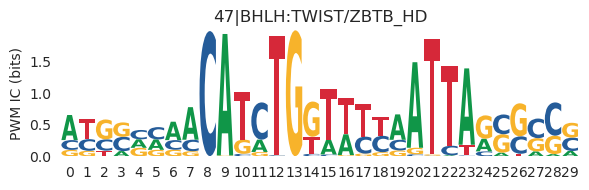

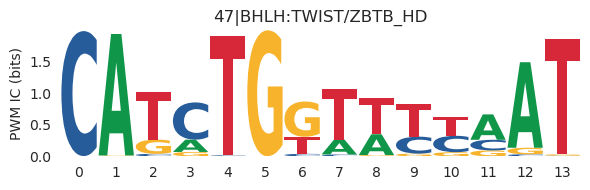

In [40]:
plot_logo(ppm_dict['pos.Average_303__merged_pattern_0'].T, get_motif_name('pos.Average_303__merged_pattern_0'), type = "PPM")
plot_logo(ppm_dict['pos.Average_303__merged_pattern_0'].T, get_motif_name('pos.Average_303__merged_pattern_0'), type = "PPM", plot_IC=True)
plot_logo(ppm_trimmed_dict['pos.Average_303__merged_pattern_0'].T, get_motif_name('pos.Average_303__merged_pattern_0'), type = "PPM", plot_IC=True)

# Convert CWMs to PPMs and write to MEME format

This is repeating the conversion from above, but now we write them to a MEME file.
Structure of the MoDISco h5 object:

```
h5
└── pos_patterns
	|-- pos.pattern_0
	└── pos.pattern_1
└── neg_patterns
	└── pattern_2
```

In [42]:
meme_out = hdma_chrombpnet_path + "02-compendium/modisco_compiled_anno/modisco_compiled_unique.PPM.memedb.txt"
write_cwm_ppm_to_meme(modisco_obj, motifs_compiled_unique, meme_out)

0


100%|██████████| 29/29 [00:00<00:00, 1476.99it/s]


Writing neg.Average_12__merged_pattern_0: 456|ZEB/SNAI
Writing neg.Average_12__merged_pattern_12: 457|ZEB/SNAI_ZEB/SNAI#1
Writing neg.Average_12__merged_pattern_2: 458|ZEB/SNAI_ZEB/SNAI#2
Writing neg.Average_12__merged_pattern_3: 460|ZEB/SNAI_ZEB/SNAI#4
Writing neg.Average_12__merged_pattern_4: 459|ZEB/SNAI_ZEB/SNAI#3
Writing neg.Average_12__merged_pattern_6: 96|BHLH_ZEB/SNAI_ZEB/SNAI
Writing neg.Average_12__merged_pattern_8: 461|ZEB/SNAI_ZEB/SNAI#5
Writing neg.Average_14__merged_pattern_0: 372|NFYrepressive
Writing neg.Average_15__merged_pattern_0: 455|YY1/2repressive
Writing neg.Average_15__merged_pattern_1: 507|unresolved,repressive,YY1/2-like
Writing neg.Average_16__merged_pattern_0: 506|unresolved,repressive#2
Writing neg.Heart__Heart_c1__neg_patterns.pattern_0__merged_pattern_0: 508|unresolved,repressive,ZEB/SNAI-like
Writing neg.Heart__Heart_c3__neg_patterns.pattern_1__merged_pattern_0: 333|HIC
Writing neg.Thymus__Average_4__merged_pattern_2: 505|unresolved,repressive#1
Writing 

 21%|██        | 171/805 [00:00<00:00, 1709.43it/s]

Writing pos.Average_112__merged_pattern_0: 499|unresolved,NFY-like
Writing pos.Average_115__merged_pattern_0: 150|CTCF#4
Writing pos.Average_116__merged_pattern_0: 102|BZIP:ATF/CREB#4
Writing pos.Average_159__merged_pattern_0: 400|NRF1
Writing pos.Average_159__merged_pattern_5: 151|CTCF#5
Writing pos.Average_161__merged_pattern_0: 462|ZNF143#1
Writing pos.Average_161__merged_pattern_1: 463|ZNF143#2
Writing pos.Average_161__merged_pattern_3: 464|ZNF143#3
Writing pos.Average_161__merged_pattern_6: 213|ETS:ETS/SIX
Writing pos.Average_161__merged_pattern_7: 465|ZNF143#4
Writing pos.Average_190__merged_pattern_0: 162|ETS:ELF/ETV_ETS:ELF/ETV#1
Writing pos.Average_190__merged_pattern_3: 169|ETS:ELF/SPIB_ETS:ELF/SPIB#1
Writing pos.Average_207__merged_pattern_0: 325|HD:SIX/ZNF
Writing pos.Average_207__merged_pattern_1: 322|HD:PITX/OTX_HD:SIX/ZNF
Writing pos.Average_207__merged_pattern_2: 127|BZIP:DBP/HLF#2
Writing pos.Average_212__merged_pattern_0: 436|SP/KLF
Writing pos.Average_212__merged_pat

...

 68%|██████▊   | 551/805 [00:00<00:00, 1527.67it/s]

Writing pos.Average_286__merged_pattern_4: 451|TEAD#2
Writing pos.Average_286__merged_pattern_5: 185|ETS:ELF/SPIB_FOX
Writing pos.Average_286__merged_pattern_6: 144|BZIP:FOSL/JUND_TEAD
Writing pos.Average_286__merged_pattern_7: 160|ETS:ELF/ETV#4
Writing pos.Average_286__merged_pattern_8: 285|GATA_TEAD
Writing pos.Average_286__merged_pattern_9: 147|BZIP:MAFG/MAFF_TEAD
Writing pos.Average_287__merged_pattern_0: 132|BZIP:FOSL/JUND#1
Writing pos.Average_287__merged_pattern_1: 146|BZIP:MAFG/MAFF_BZIP:MAFG/MAFF
Writing pos.Average_287__merged_pattern_10: 135|BZIP:FOSL/JUND#4
Writing pos.Average_287__merged_pattern_11: 493|unresolved,HD-like
Writing pos.Average_287__merged_pattern_12: 32|BHLH:TFAP/MYOD_BZIP:FOSL/JUND#2
Writing pos.Average_287__merged_pattern_13: 137|BZIP:FOSL/JUND#6
Writing pos.Average_287__merged_pattern_15: 114|BZIP:BACH/NFE#2
Writing pos.Average_287__merged_pattern_16: 139|BZIP:FOSL/JUND_ETS
Writing pos.Average_287__merged_pattern_2: 142|BZIP:FOSL/JUND_NR:ESRRA/NR5A#1
Writ

100%|██████████| 805/805 [00:00<00:00, 1395.19it/s]

Writing pos.Average_306__merged_pattern_101: 186|ETS:ELF/SPIB_GATA#1
Writing pos.Average_306__merged_pattern_11: 226|ETS_SP/KLF#1
Writing pos.Average_306__merged_pattern_12: 111|BZIP:ATF/CREB_TEAD#1
Writing pos.Average_306__merged_pattern_13: 447|STAT
Writing pos.Average_306__merged_pattern_14: 290|GRHL_TEAD#1
Writing pos.Average_306__merged_pattern_16: 180|ETS:ELF/SPIB_ETS:ELF/SPIB#5
Writing pos.Average_306__merged_pattern_17: 173|ETS:ELF/SPIB_ETS:ELF/SPIB#13
Writing pos.Average_306__merged_pattern_18: 212|ETS:ERG/FLI
Writing pos.Average_306__merged_pattern_19: 352|NFAT_NFIhalf#1
Writing pos.Average_306__merged_pattern_20: 176|ETS:ELF/SPIB_ETS:ELF/SPIB#16
Writing pos.Average_306__merged_pattern_21: 183|ETS:ELF/SPIB_ETS:ELF/SPIB#8
Writing pos.Average_306__merged_pattern_23: 182|ETS:ELF/SPIB_ETS:ELF/SPIB#7
Writing pos.Average_306__merged_pattern_24: 477|unresolved#2
Writing pos.Average_306__merged_pattern_25: 217|ETS_FOX#1
Writing pos.Average_306__merged_pattern_27: 181|ETS:ELF/SPIB_ETS

508


Repeat this procedure with trimmed CWMs.

In [43]:
meme_out = hdma_chrombpnet_path + "02-compendium/modisco_compiled_anno/modisco_compiled_unique.trimmed.PPM.memedb.txt"
write_cwm_ppm_to_meme(modisco_obj, motifs_compiled_unique, meme_out, trim=True)

0


100%|██████████| 29/29 [00:00<00:00, 1340.36it/s]


Writing neg.Average_12__merged_pattern_0: 456|ZEB/SNAI
@ trimming CWMs...
Writing neg.Average_12__merged_pattern_12: 457|ZEB/SNAI_ZEB/SNAI#1
@ trimming CWMs...
Writing neg.Average_12__merged_pattern_2: 458|ZEB/SNAI_ZEB/SNAI#2
@ trimming CWMs...
Writing neg.Average_12__merged_pattern_3: 460|ZEB/SNAI_ZEB/SNAI#4
@ trimming CWMs...
Writing neg.Average_12__merged_pattern_4: 459|ZEB/SNAI_ZEB/SNAI#3
@ trimming CWMs...
Writing neg.Average_12__merged_pattern_6: 96|BHLH_ZEB/SNAI_ZEB/SNAI
@ trimming CWMs...
Writing neg.Average_12__merged_pattern_8: 461|ZEB/SNAI_ZEB/SNAI#5
@ trimming CWMs...
Writing neg.Average_14__merged_pattern_0: 372|NFYrepressive
@ trimming CWMs...
Writing neg.Average_15__merged_pattern_0: 455|YY1/2repressive
@ trimming CWMs...
Writing neg.Average_15__merged_pattern_1: 507|unresolved,repressive,YY1/2-like
@ trimming CWMs...
Writing neg.Average_16__merged_pattern_0: 506|unresolved,repressive#2
@ trimming CWMs...
Writing neg.Heart__Heart_c1__neg_patterns.pattern_0__merged_patter

 14%|█▎        | 109/805 [00:00<00:00, 1088.49it/s]

Writing pos.Average_112__merged_pattern_0: 499|unresolved,NFY-like
@ trimming CWMs...
Writing pos.Average_115__merged_pattern_0: 150|CTCF#4
@ trimming CWMs...
Writing pos.Average_116__merged_pattern_0: 102|BZIP:ATF/CREB#4
@ trimming CWMs...
Writing pos.Average_159__merged_pattern_0: 400|NRF1
@ trimming CWMs...
Writing pos.Average_159__merged_pattern_5: 151|CTCF#5
@ trimming CWMs...
Writing pos.Average_161__merged_pattern_0: 462|ZNF143#1
@ trimming CWMs...
Writing pos.Average_161__merged_pattern_1: 463|ZNF143#2
@ trimming CWMs...
Writing pos.Average_161__merged_pattern_3: 464|ZNF143#3
@ trimming CWMs...
Writing pos.Average_161__merged_pattern_6: 213|ETS:ETS/SIX
@ trimming CWMs...
Writing pos.Average_161__merged_pattern_7: 465|ZNF143#4
@ trimming CWMs...
Writing pos.Average_190__merged_pattern_0: 162|ETS:ELF/ETV_ETS:ELF/ETV#1
@ trimming CWMs...
Writing pos.Average_190__merged_pattern_3: 169|ETS:ELF/SPIB_ETS:ELF/SPIB#1
@ trimming CWMs...
Writing pos.Average_207__merged_pattern_0: 325|HD:S

...

@ trimming CWMs...
Writing pos.Average_276__merged_pattern_27: 329|HD_HD#4
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_3: 7|BHLH:ATOH/NEUROD#1
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_30: 245|FOX_NFI
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_35: 345|MEF2_NFI
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_37: 84|BHLH_NFI
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_39: 346|MEF2_NFIhalf#1
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_4: 306|HD:MEIS/TGIF/TBX
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_41: 86|BHLH_NFI#2
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_42: 362|NFIhalf_NFIhalf#2
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_43: 164|ETS:ELF/ETV_NFY
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_44: 330|HD_NFI#1
@ trimming CWMs...
Writing pos.Average_276__merged_pattern_48: 202|ETS:ELF/SPIB_RUNX#2
@ trimming CWMs...
Writing pos.Average_276_

 78%|███████▊  | 631/805 [00:00<00:00, 1267.45it/s]

@ trimming CWMs...
Writing pos.Average_295__merged_pattern_1: 496|unresolved,MEF-like#1
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_11: 81|BHLH_MEF2#2
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_13: 347|MEF2_NFIhalf#2
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_14: 82|BHLH_MEF2#3
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_15: 349|MEF2_TBP
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_16: 311|HD:MEIS/TGIF/TBX_MEF2
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_19: 275|GATA_MEF2#3
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_20: 276|GATA_MEF2#4
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_22: 274|GATA_MEF2#2
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_3: 80|BHLH_MEF2#1
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_4: 83|BHLH_MEF2#4
@ trimming CWMs...
Writing pos.Average_295__merged_pattern_5: 277|GATA_MEF2#5
@ trimming CWMs...
Writing pos.Average_2

100%|██████████| 805/805 [00:00<00:00, 1207.91it/s]


@ trimming CWMs...
Writing pos.Liver__Average_407__merged_pattern_0: 261|GATA#2
@ trimming CWMs...
Writing pos.Liver__Average_407__merged_pattern_1: 323|HD:PITX/OTX_SP/KLF
@ trimming CWMs...
Writing pos.Liver__Liver_c0__pos_patterns.pattern_26__merged_pattern_0: 442|SP/KLF_SP/KLF#6
@ trimming CWMs...
Writing pos.Liver__Liver_c1__pos_patterns.pattern_38__merged_pattern_0: 236|FOX#5
@ trimming CWMs...
Writing pos.Liver__Liver_c4__pos_patterns.pattern_42__merged_pattern_0: 256|FOX_NR:NR2F/RXRG
@ trimming CWMs...
Writing pos.Liver__Liver_c5__pos_patterns.pattern_20__merged_pattern_0: 443|SP/KLF_unresolved
@ trimming CWMs...
Writing pos.Lung__Lung_c0__pos_patterns.pattern_51__merged_pattern_0: 486|unresolved,BZIP-like
@ trimming CWMs...
Writing pos.Lung__Lung_c4__pos_patterns.pattern_36__merged_pattern_0: 364|NFIhalf_NKX
@ trimming CWMs...
Writing pos.Muscle__Muscle_c18__pos_patterns.pattern_24__merged_pattern_0: 369|NFY_NFY#2
@ trimming CWMs...
Writing pos.Skin__Average_96__merged_pattern_

# Inspect filtered object

In [71]:
filtered_modisco_h5_path = hdma_chrombpnet_path + "02-compendium/modisco_compiled/modisco_compiled_filtered.h5"

In [72]:
# load up the modisco compiled object
modisco_obj_filt = h5py.File(filtered_modisco_h5_path)

In [73]:
modisco_obj_filt.keys()

<KeysViewHDF5 ['neg_patterns', 'pos_patterns']>

In [74]:
len(modisco_obj_filt['pos_patterns'])
len(modisco_obj_filt['neg_patterns'])

722

20

In [75]:
sup_table_6 = motifs_compiled_unique.copy()
sup_table_6.rename(columns={'pattern': 'merged_pattern'}, inplace=True)
sup_table_6[["motif_name", "merged_pattern"]]

,motif_name,merged_pattern
0,0|AP-2,pos.Average_272__merged_pattern_1
1,1|AP-2_BHLH,pos.Average_272__merged_pattern_4
2,2|ATF4/CEBPG,pos.Average_85__merged_pattern_1
3,3|BANP/ZBTB33,pos.Average_64__merged_pattern_0
4,4|BCL11A/Brepressive,neg.Thymus__Average_6__merged_pattern_0
...,...,...
504,"504|unresolved,palindromic#2",pos.Skin__Skin_c2__pos_patterns.pattern_45__merged_pattern_0
505,"505|unresolved,repressive#1",neg.Thymus__Average_4__merged_pattern_2
506,"506|unresolved,repressive#2",neg.Average_16__merged_pattern_0
507,"507|unresolved,repressive,YY1/2-like",neg.Average_15__merged_pattern_1


In [76]:
# helper function to get the pattern given the motif name
def get_pattern_name(motif_name):
	"""
	Get the MoDISco pattern name '<pattern_class>.pattern_<X>', given the motif name
	"""
	return sup_table_6[sup_table_6["motif_name"] == motif_name]['merged_pattern'].values[0]


motif = "0|AP-2"
pattern = get_pattern_name(motif)
pattern

'pos.Average_272__merged_pattern_1'

In [77]:
modisco_obj_filt['pos_patterns'][pattern].keys()

<KeysViewHDF5 ['contrib_scores', 'hypothetical_contribs', 'seqlets', 'sequence']>

In [78]:
print(modisco_obj_filt['pos_patterns'][pattern]['contrib_scores'][()].shape)

(30, 4)
